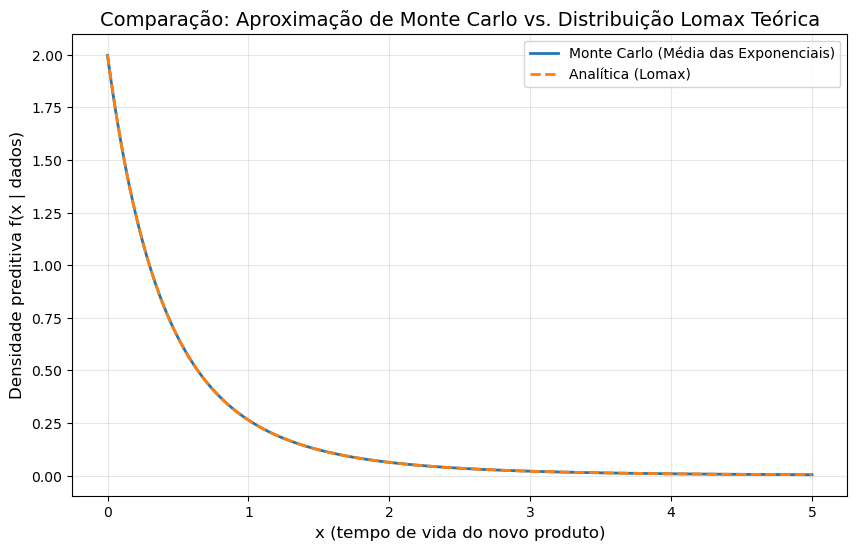

Diferença máxima entre as curvas: 0.003392


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, lomax

# ------------------------------------------------------------
# 1. DEFINIR OS PARÂMETROS DA POSTERIORI (a' e b')
#    (Aqui você coloca os valores do seu exemplo real)
#    Vou usar a' = 4 e b' = 2 apenas para demonstrar o gráfico.
# ------------------------------------------------------------
a_linha = 4   # shape da Gama posteriori
b_linha = 2   # rate (taxa) da Gama posteriori

# ------------------------------------------------------------
# 2. SIMULAR UMA AMOSTRA GRANDE DE lambda DA POSTERIORI
#    Vamos usar S = 100.000 simulações para boa precisão.
# ------------------------------------------------------------
S = 100000
# A função np.random.gamma usa (shape, scale). Escala = 1/rate.
lambda_sim = np.random.gamma(shape=a_linha, scale=1/b_linha, size=S)

# ------------------------------------------------------------
# 3. CRIAR O VETOR DE x (GRADE) DE 0 A 5, PASSO 0.01
# ------------------------------------------------------------
x_grid = np.arange(0, 5.01, 0.01)  # 501 pontos

# ------------------------------------------------------------
# 4. CALCULAR A MÉDIA DE MONTE CARLO PARA CADA x
#    Para cada x, calculamos mean( lambda * exp(-lambda * x) )
#    Usamos list comprehension (ou vetorização para ficar mais rápido)
# ------------------------------------------------------------
pred_mc = np.array([
    np.mean(lambda_sim * np.exp(-lambda_sim * x)) 
    for x in x_grid
])

# ------------------------------------------------------------
# 5. CALCULAR A DENSIDADE ANALÍTICA DA LOMAX
#    A Lomax no scipy: pdf(x, c, scale) = c * scale^c / (scale + x)^(c+1)
#    Comparando com a fórmula a' * (b')^a' / (b' + x)^(a'+1),
#    vemos que c = a' e scale = b'.
# ------------------------------------------------------------
pred_analitica = lomax.pdf(x_grid, c=a_linha, scale=b_linha)

# ------------------------------------------------------------
# 6. FAZER O GRÁFICO DE LINHA E COMPARAR
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(x_grid, pred_mc, linewidth=2, label='Monte Carlo (Média das Exponenciais)')
plt.plot(x_grid, pred_analitica, '--', linewidth=2, label='Analítica (Lomax)')
plt.xlabel('x (tempo de vida do novo produto)', fontsize=12)
plt.ylabel('Densidade preditiva f(x | dados)', fontsize=12)
plt.title('Comparação: Aproximação de Monte Carlo vs. Distribuição Lomax Teórica', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# (Opcional) Verificar numericamente a diferença máxima para ter certeza
diferenca_max = np.max(np.abs(pred_mc - pred_analitica))
print(f'Diferença máxima entre as curvas: {diferenca_max:.6f}')